<a href="https://colab.research.google.com/github/Sangmeshwar-Naik/Mental-chatbot/blob/main/Brain_Tumor_BraTS2021_LocalPath_Colab_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain Tumor MRI Project — BraTS 2021
## Local Windows Dataset + Colab Workflow

### Your current Windows dataset

```text
C:\Users\Sangmeshwar Naik\Downloads\BraTS2021_Training_Data
```

### IMPORTANT
A **hosted Google Colab runtime cannot directly read a Windows path such as
`C:\Users\...`**. The path exists on your PC, while hosted Colab runs on a
separate cloud machine.

This notebook therefore provides two workflows:

**Workflow A — Local Runtime**
- Run Jupyter/Colab connected to your Windows PC.
- The exact Windows path can be used directly.
- Computation/GPU comes from your PC, not Google's hosted GPU.

**Workflow B — Hosted Colab**
- You must transfer the dataset to the hosted runtime (for example by uploading
  a ZIP, or using another cloud storage location).
- Your Windows `C:\...` path cannot be referenced directly.

For your current unzipped dataset, this notebook first prepares the **Local
Runtime path workflow**, because it matches your exact folder.

## 1. Choose the runtime

If you want to use the exact Windows path shown above, connect this notebook to a **local runtime**. If you are using normal hosted Colab, skip the Windows-path cell and use a cloud/ZIP transfer method instead.

In [1]:
import os
import sys
import platform

print("Python:", sys.version)
print("Platform:", platform.platform())

# Your exact dataset path:
DATASET_PATH = r"C:\Users\Sangmeshwar Naik\Downloads\BraTS2021_Training_Data"

print("\nDataset path:")
print(DATASET_PATH)
print("\nPath exists:", os.path.exists(DATASET_PATH))

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.39

Dataset path:
C:\Users\Sangmeshwar Naik\Downloads\BraTS2021_Training_Data

Path exists: False


## 2. GPU check

This checks the GPU available to the **current runtime**. In a local runtime this is your computer's GPU. In hosted Colab it is the Colab-assigned GPU.

In [2]:
try:
    import torch
    print("PyTorch version:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())

    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
    else:
        print("No CUDA GPU detected.")
except ImportError:
    print("PyTorch is not installed yet.")

PyTorch version: 2.11.0+cpu
CUDA available: False
No CUDA GPU detected.


## 3. Install required libraries

In [3]:
# In a hosted Colab/local Jupyter environment, run this if required.
!pip install -q nibabel SimpleITK numpy pandas matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 19.0 MB/s eta 0:00:00


In [4]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
import SimpleITK as sitk

print("Libraries imported successfully.")

Libraries imported successfully.


## 4. Inspect the BraTS 2021 folder

In [6]:
from google.colab import files

uploaded = files.upload()

Saving BraTS2021_01020_flair.nii.gz to BraTS2021_01020_flair.nii.gz
Saving BraTS2021_01020_seg.nii.gz to BraTS2021_01020_seg.nii.gz
Saving BraTS2021_01020_t1.nii.gz to BraTS2021_01020_t1.nii.gz
Saving BraTS2021_01020_t1ce.nii.gz to BraTS2021_01020_t1ce.nii.gz
Saving BraTS2021_01020_t2.nii.gz to BraTS2021_01020_t2.nii.gz


## 5. Find patient folders

In [9]:
patient_dirs = []

# Define entries by listing the dataset directory if it exists, otherwise fall back to current directory
if os.path.exists(DATASET_PATH):
    entries = os.listdir(DATASET_PATH)
    search_path = DATASET_PATH
else:
    print(f"Warning: {DATASET_PATH} does not exist. Scanning current working directory instead...")
    entries = os.listdir('.')
    search_path = '.'

for item in entries:
    full_path = os.path.join(search_path, item)
    if os.path.isdir(full_path):
        patient_dirs.append(full_path)

print("Patient folders found:", len(patient_dirs))
print("\nFirst 10:")
for path in patient_dirs[:10]:
    print(os.path.basename(path))

Patient folders found: 2

First 10:
.config
sample_data


## 6. Select your patient

In [11]:
PATIENT_ID = "BraTS2021_01020"

# Fallback to current directory if the local path doesn't exist
if not os.path.exists(DATASET_PATH):
    PATIENT_PATH = "."
else:
    PATIENT_PATH = os.path.join(DATASET_PATH, PATIENT_ID)

print("Patient path:", PATIENT_PATH)

# In Colab, the files were uploaded directly to the current directory (PATIENT_PATH = ".").
# Let's verify that the uploaded files for our patient actually exist in this directory.
expected_sample_file = f"{PATIENT_ID}_flair.nii.gz"
if not os.path.exists(os.path.join(PATIENT_PATH, expected_sample_file)):
    raise FileNotFoundError(
        f"Could not find files for {PATIENT_ID} in '{PATIENT_PATH}'. "
        "Please ensure your .nii.gz files are uploaded properly."
    )

print("\nPatient files found in directory:")
for f in sorted(os.listdir(PATIENT_PATH)):
    if PATIENT_ID in f and f.endswith(".nii.gz"):
        print(" ", f)

Patient path: .

Patient files found in directory:
  BraTS2021_01020_flair.nii.gz
  BraTS2021_01020_seg.nii.gz
  BraTS2021_01020_t1.nii.gz
  BraTS2021_01020_t1ce.nii.gz
  BraTS2021_01020_t2.nii.gz


## 7. Find the five MRI/segmentation files

In [12]:
modalities = ["flair", "t1", "t1ce", "t2", "seg"]
patient_files = {}

for mod in modalities:
    filename = f"{PATIENT_ID}_{mod}.nii.gz"
    filepath = os.path.join(PATIENT_PATH, filename)

    if os.path.exists(filepath):
        patient_files[mod] = filepath
        print(f"{mod:5s}: FOUND")
    else:
        print(f"{mod:5s}: MISSING")

if len(patient_files) != 5:
    raise FileNotFoundError(
        "Not all five expected files were found. "
        "Check the patient folder and naming."
    )

flair: FOUND
t1   : FOUND
t1ce : FOUND
t2   : FOUND
seg  : FOUND


## 8. Load FLAIR, T1, T1ce, T2 and segmentation

In [13]:
patient_data = {}
patient_nii = {}

for mod, filepath in patient_files.items():
    nii = nib.load(filepath)
    patient_nii[mod] = nii
    patient_data[mod] = nii.get_fdata()

    print(f"{mod:5s}: shape={patient_data[mod].shape}, dtype={patient_data[mod].dtype}")

flair: shape=(240, 240, 155), dtype=float64
t1   : shape=(240, 240, 155), dtype=float64
t1ce : shape=(240, 240, 155), dtype=float64
t2   : shape=(240, 240, 155), dtype=float64
seg  : shape=(240, 240, 155), dtype=float64


## 9. Check segmentation labels

In [14]:
seg_data = patient_data["seg"]

labels, counts = np.unique(seg_data, return_counts=True)

print("Segmentation labels:")
for label, count in zip(labels, counts):
    print(f"  Label {int(label)}: {int(count):,} voxels")

Segmentation labels:
  Label 0: 8,754,538 voxels
  Label 1: 13,939 voxels
  Label 2: 121,673 voxels
  Label 4: 37,850 voxels


## 10. Find tumor-containing slices

In [15]:
tumor_mask = seg_data > 0

tumor_slices = np.where(
    np.any(tumor_mask, axis=(0, 1))
)[0]

if len(tumor_slices) == 0:
    raise ValueError("No non-zero tumor voxels found.")

slice_idx = int(tumor_slices[len(tumor_slices) // 2])

print("Tumor-containing slices:", len(tumor_slices))
print("First tumor slice:", int(tumor_slices[0]))
print("Last tumor slice:", int(tumor_slices[-1]))
print("Representative slice:", slice_idx)

Tumor-containing slices: 67
First tumor slice: 29
Last tumor slice: 95
Representative slice: 62


## 11. Display FLAIR

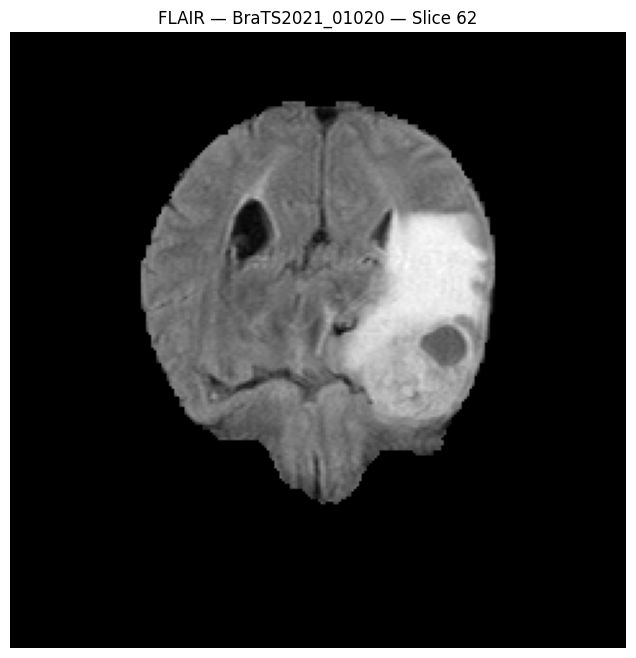

In [16]:
flair = patient_data["flair"]

plt.figure(figsize=(8, 8))
plt.imshow(
    flair[:, :, slice_idx].T,
    cmap="gray",
    origin="lower"
)
plt.title(f"FLAIR — {PATIENT_ID} — Slice {slice_idx}")
plt.axis("off")
plt.show()

## 12. Display segmentation

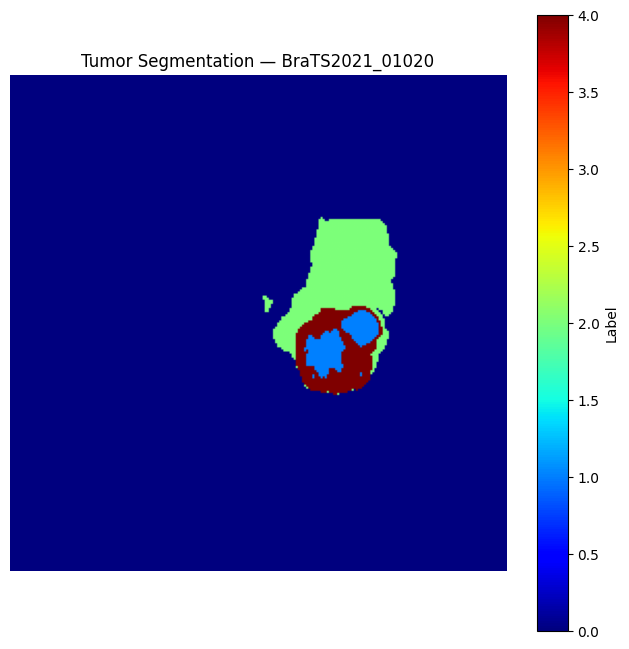

In [17]:
seg_slice = seg_data[:, :, slice_idx]

plt.figure(figsize=(8, 8))
plt.imshow(
    seg_slice.T,
    cmap="jet",
    origin="lower"
)
plt.title(f"Tumor Segmentation — {PATIENT_ID}")
plt.axis("off")
plt.colorbar(label="Label")
plt.show()

## 13. Display MRI + tumor mask overlay

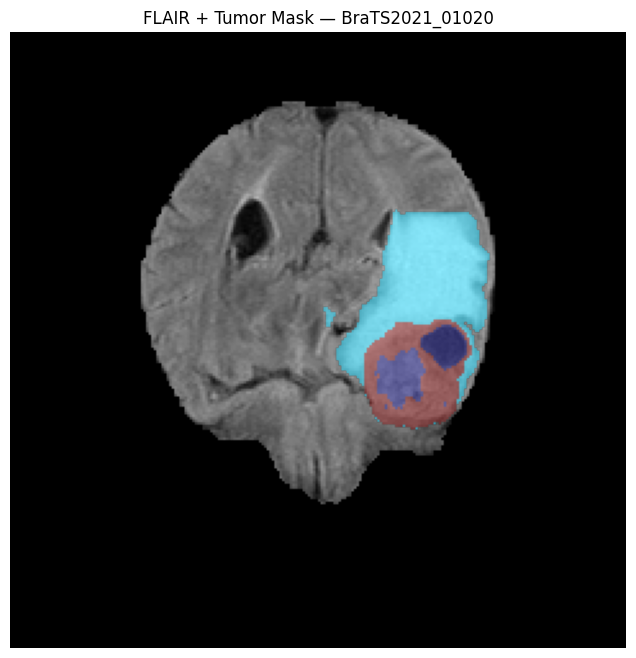

In [18]:
plt.figure(figsize=(8, 8))

plt.imshow(
    flair[:, :, slice_idx].T,
    cmap="gray",
    origin="lower"
)

masked_seg = np.ma.masked_where(
    seg_slice.T == 0,
    seg_slice.T
)

plt.imshow(
    masked_seg,
    cmap="jet",
    alpha=0.45,
    origin="lower"
)

plt.title(f"FLAIR + Tumor Mask — {PATIENT_ID}")
plt.axis("off")
plt.show()

## 14. Read voxel spacing and calculate tumor volume

In [19]:
seg_nii = patient_nii["seg"]

spacing = seg_nii.header.get_zooms()[:3]
voxel_volume_mm3 = float(np.prod(spacing))

tumor_voxels = int(np.sum(seg_data > 0))
tumor_volume_mm3 = tumor_voxels * voxel_volume_mm3
tumor_volume_cm3 = tumor_volume_mm3 / 1000.0

print("Voxel spacing (mm):", spacing)
print("Voxel volume (mm³):", voxel_volume_mm3)
print("Tumor voxels:", f"{tumor_voxels:,}")
print("Tumor volume (mm³):", f"{tumor_volume_mm3:,.3f}")
print("Tumor volume (cm³):", f"{tumor_volume_cm3:,.3f}")

Voxel spacing (mm): (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Voxel volume (mm³): 1.0
Tumor voxels: 173,462
Tumor volume (mm³): 173,462.000
Tumor volume (cm³): 173.462


## 15. Calculate component volumes

In [20]:
component_results = []

for label in sorted(np.unique(seg_data)):
    if label == 0:
        continue

    voxel_count = int(np.sum(seg_data == label))
    volume_mm3 = voxel_count * voxel_volume_mm3

    component_results.append({
        "patient_id": PATIENT_ID,
        "label": int(label),
        "voxel_count": voxel_count,
        "volume_mm3": volume_mm3,
        "volume_cm3": volume_mm3 / 1000.0
    })

component_df = pd.DataFrame(component_results)
component_df

,patient_id,label,voxel_count,volume_mm3,volume_cm3
0,BraTS2021_01020,1,13939,13939.0,13.939
1,BraTS2021_01020,2,121673,121673.0,121.673
2,BraTS2021_01020,4,37850,37850.0,37.850


## 16. Create a patient summary

In [21]:
patient_summary = pd.DataFrame([{
    "patient_id": PATIENT_ID,
    "tumor_voxels": tumor_voxels,
    "voxel_volume_mm3": voxel_volume_mm3,
    "tumor_volume_mm3": tumor_volume_mm3,
    "tumor_volume_cm3": tumor_volume_cm3
}])

patient_summary

,patient_id,tumor_voxels,voxel_volume_mm3,tumor_volume_mm3,tumor_volume_cm3
0,BraTS2021_01020,173462,1.0,173462.0,173.462


## 17. Reusable tumor-volume function

In [22]:
def calculate_tumor_volume(seg_path):
    nii = nib.load(seg_path)
    seg = nii.get_fdata()

    spacing = nii.header.get_zooms()[:3]
    voxel_volume_mm3 = float(np.prod(spacing))

    tumor_voxels = int(np.sum(seg > 0))
    volume_mm3 = tumor_voxels * voxel_volume_mm3

    return {
        "tumor_voxels": tumor_voxels,
        "voxel_volume_mm3": voxel_volume_mm3,
        "tumor_volume_mm3": volume_mm3,
        "tumor_volume_cm3": volume_mm3 / 1000.0
    }

calculate_tumor_volume(patient_files["seg"])

{'tumor_voxels': 173462,
 'voxel_volume_mm3': 1.0,
 'tumor_volume_mm3': 173462.0,
 'tumor_volume_cm3': 173.462}

## 18. Process all patient segmentation masks

In [23]:
seg_paths = sorted(
    glob.glob(
        os.path.join(DATASET_PATH, "**", "*_seg.nii.gz"),
        recursive=True
    )
)

print("Segmentation files found:", len(seg_paths))

results = []

for seg_path in seg_paths:
    filename = os.path.basename(seg_path)
    patient_id = filename.replace("_seg.nii.gz", "")

    try:
        result = calculate_tumor_volume(seg_path)
        results.append({
            "patient_id": patient_id,
            **result
        })
    except Exception as e:
        print("Error:", patient_id, e)

volume_df = pd.DataFrame(results)

print("Patients processed:", len(volume_df))
volume_df.head()

Segmentation files found: 0
Patients processed: 0


""


## 19. Save the derived tumor-volume dataset

In [24]:
RESULTS_DIR = os.path.join(DATASET_PATH, "_project_results")
os.makedirs(RESULTS_DIR, exist_ok=True)

volume_csv = os.path.join(RESULTS_DIR, "tumor_volumes.csv")
volume_df.to_csv(volume_csv, index=False)

component_csv = os.path.join(
    RESULTS_DIR,
    f"{PATIENT_ID}_component_volumes.csv"
)
component_df.to_csv(component_csv, index=False)

print("Saved:")
print(volume_csv)
print(component_csv)

Saved:
C:\Users\Sangmeshwar Naik\Downloads\BraTS2021_Training_Data/_project_results/tumor_volumes.csv
C:\Users\Sangmeshwar Naik\Downloads\BraTS2021_Training_Data/_project_results/BraTS2021_01020_component_volumes.csv


## 20. Baseline MRI comparison function

This function will be used later when we have **multiple scans from the same patient**.

Do not compare `BraTS2021_01020` with `BraTS2021_01021` as if they were two dates.
Those are different patients.

In [25]:
def compare_tumor_volumes(previous_volume, current_volume, days):
    if previous_volume <= 0:
        raise ValueError("Previous volume must be greater than zero.")

    if days <= 0:
        raise ValueError("Days must be greater than zero.")

    absolute_change = current_volume - previous_volume

    percentage_change = (
        absolute_change / previous_volume
    ) * 100.0

    growth_rate = absolute_change / days

    return {
        "previous_volume_cm3": previous_volume,
        "current_volume_cm3": current_volume,
        "days": days,
        "absolute_change_cm3": absolute_change,
        "percentage_change": percentage_change,
        "growth_rate_cm3_per_day": growth_rate
    }

# Example only — not a real patient time series.
pd.DataFrame([
    compare_tumor_volumes(10.0, 12.0, 30)
])

,previous_volume_cm3,current_volume_cm3,days,absolute_change_cm3,percentage_change,growth_rate_cm3_per_day
0,10.0,12.0,30,2.0,20.0,0.066667


# Next stage

Once the BraTS 2021 pipeline works, we will add a **longitudinal dataset**
with repeated scans from the same patient.

The final pipeline will be:

```text
BraTS 2021
   ↓
Tumor segmentation
   ↓
Tumor volume

Longitudinal dataset
   ↓
Same patient + multiple dates
   ↓
Registration
   ↓
Segmentation / masks
   ↓
Tumor volumes
   ↓
MRI comparison
   ↓
Growth trajectory
   ↓
Future-growth model
   ↓
Dashboard
```

**Do not invent time intervals for BraTS 2021 cross-sectional patients.**